
## Lab 2: Seaborn (From Matplolib and pandas to seaborn)

### Estudiante: Estiven Castrillon, 1040570656

In [69]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

1. Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galon.csv. Contruya el fit al $95$ C.L. Usar `seaborn`. Give some conclusions.

In [70]:
url_millas_por_galon = "../../Sesiones/seaborn/millas_por_galon.csv"
df_millas = pd.read_csv(url_millas_por_galon)
df_millas.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320



Resumen:
              mpg  horsepower
count  398.000000  392.000000
mean    23.514573  104.469388
std      7.815984   38.491160
min      9.000000   46.000000
25%     17.500000   75.000000
50%     23.000000   93.500000
75%     29.000000  126.000000
max     46.600000  230.000000

Medidas adicionales:
              mpg  horsepower
median  23.000000   93.500000
skew     0.457066    1.087326
kurt    -0.510781    0.696947

Correlación:
                 mpg  horsepower
mpg         1.000000   -0.778427
horsepower -0.778427    1.000000


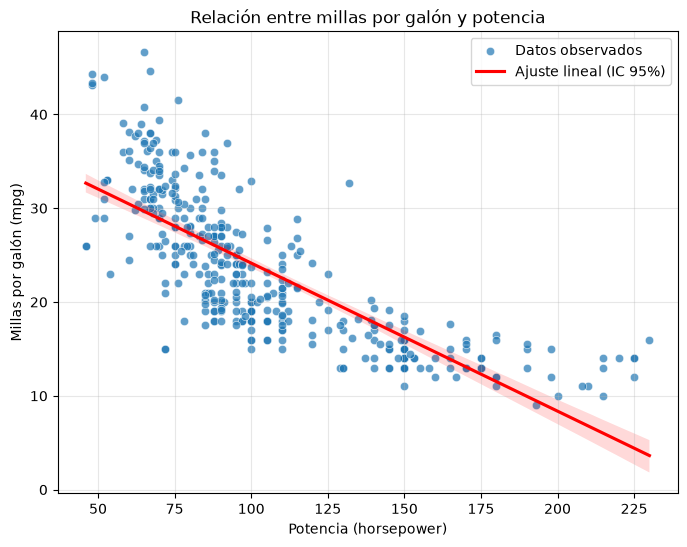

In [71]:
print("\nResumen:")
print(df_millas[["mpg", "horsepower"]].describe())

print("\nMedidas adicionales:")
print(df_millas[["mpg", "horsepower"]].agg(["median", "skew", "kurt"]))

print("\nCorrelación:")
print(df_millas[["mpg", "horsepower"]].corr())


plt.figure(figsize=(8, 6))

ax = sns.scatterplot(
    data=df_millas,
    x="horsepower",
    y="mpg",
    alpha=0.7,
    label="Datos observados"
)

sns.regplot(
    data=df_millas,
    x="horsepower",
    y="mpg",
    scatter=False,
    ci=95,
    label="Ajuste lineal (IC 95%)",
    line_kws={"color": "red", "label": "Ajuste lineal (IC 95%)"},
    ax=ax
)

ax.set(
    title="Relación entre millas por galón y potencia",
    xlabel="Potencia (horsepower)",
    ylabel="Millas por galón (mpg)"
)
ax.grid(alpha=0.3)
ax.legend()

plt.show()

Los resultados muestran una relación negativa fuerte entre la potencia y las millas por galón, que son una cantidad de la eficiencia del motor del carro, la correlación de Pearson es (r=-0.778), lo que indica que, en general, a medida que aumenta la potencia, disminuyen las millas por galón (mpg), teniendo sentido físico por mayor requerimiento de energía para mayor potencia. 

El promedio de potencia es de aproximadamente (104.47) horsepower, mientras que el consumo promedio es de (23.51) mpg, además, la mediana de ambas variables es cercana a sus respectivos promedios, aunque horsepower presenta una asimetría positiva considerable (1.09) medido con skew, mostrando que existen carros con potencias significativamente mayores que la mayoría.

El ajuste lineal con un intervalo de confianza del 95% confirma visualmente esta tendencia negativa: la línea de regresión desciende conforme aumenta la potencia, confirmando lo que se dijo en el párrafo anterior, sin embargo, la dispersión de los datos alrededor de la recta muestra que la potencia no es el único factor que determina el rendimiento del carro.


... BIEN. SERIA BUENO IMPRIMIR LA EC. DE LA RECTA DE AJUSTE. EL AJUSTE LINEAL NO ES PERFECTO, PERO SIRVE PARA VER LA TENDENCIA. SI SE QUIERE UN AJUSTE MÁS COMPLEJO, SE PUEDE USAR POLINOMIAL O REGRESIÓN NO LINEAL.

2. Descargar el dataframe : https://github.com/anferivera/SDdiracDM/blob/master/general-scan.csv
  desde GitHUb y reconstruir la figura 6 del [trabajo](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.100.035029). Para ello usar `seaborn` y `matplolib`.

In [72]:
# Leyendo dataset con pandas desde URL
url_SD_dirac = "https://raw.githubusercontent.com/anferivera/SDdiracDM/master/general-scan.csv"
df_sd = pd.read_csv(url_SD_dirac).drop("Unnamed: 0", axis=1)
df_sd.head(2)

,MDF,MS12,MS22,LamS1H,LamS2H,LamSPH,LamS,LamSP,vS,YRD,YRC,YRA11,YRA12,YRA13,YRA21,YRA22,YRA23,YRB11,YRB12,YRB13,YRB21,YRB22,YRB23,mh1,mh2,mv3,mv2,mv1,mS1,mS2,mCha,mChi1,mChi2,XV11,XV12,XV21,XV22,XU11,XU12,XU21,XU22,vevSM,Omega,PSI,PSD,NSI,NSD,T,S,U,mueg,taumug,sv,ZH11,ZH12,ZH21,ZH22,BRh1gg,BRh2gg
0,396.848661,2.137304e+06,2.137304e+06,0.020984,0.020984,0.020052,0.0,0.217236,702.109163,0.725021,0.267003,0.0,0.076623,0.000106,0.0,0.001416,0.001439,6.754433e-10,7.723185e-09,1.104287e-08,-1.083894e-07,-4.821480e-07,-5.234661e-07,124.341412,327.441326,5.070676e-11,8.436243e-12,7.752366e-20,1462.16737,1462.16737,396.84866,125.748354,418.339459,0.105116,-0.99446,0.99446,0.105116,0.331734,-0.943373,0.943373,0.331734,244.874403,0.135,6.702000e-07,9.870000e-05,2.649000e-05,7.547000e-05,-0.021311,0.005945,0.001075,0.0,1.773785e-19,1.860000e-26,0.999293,-0.037599,0.037599,0.999293,0.002837,0.000000
1,5988.499243,1.889315e+07,1.889315e+07,0.023341,0.023341,0.000181,0.0,0.019173,329.668504,0.059422,0.973918,0.0,0.030537,0.001453,0.0,0.082603,0.014188,5.187065e-07,2.586266e-06,3.002508e-06,-2.116225e-07,-9.732642e-07,-1.090412e-06,45.647901,124.859951,5.014552e-11,8.953276e-12,3.546550e-19,4346.70574,4346.70574,5988.49920,227.030614,5988.508050,0.000065,-1.00000,1.00000,0.000065,0.001721,-0.999999,0.999999,0.001721,244.870386,0.127,8.033000e-12,8.859000e-14,7.450000e-12,6.774000e-14,0.047818,0.101726,-0.002513,0.0,1.791040e-18,2.580000e-31,0.001084,-0.999999,-0.999999,-0.001084,0.000342,0.002816


En el dataset tenemos directamente los valores de $M_{\Psi}$ en la columna `MDF`, los valores de $M_{N}$ no los dan directamente, pero según la ecuación (15) del paper, de la matriz se puede extraer:

$$
M_N = \frac{h_c v_s}{\sqrt{2}}
$$

donde según la ecuacioń (1) del paper y su texto posterior $h_c$ son los "Yukawa couplings" y $v_s$ es el "vev of the singlet scalar". En el dataset, los valores de $h_c$ están en la columna `YRC` y los valores de $v_s$ están en la columna `vS`, por lo tanto, podemos calcular $M_N$ usando estas columnas.

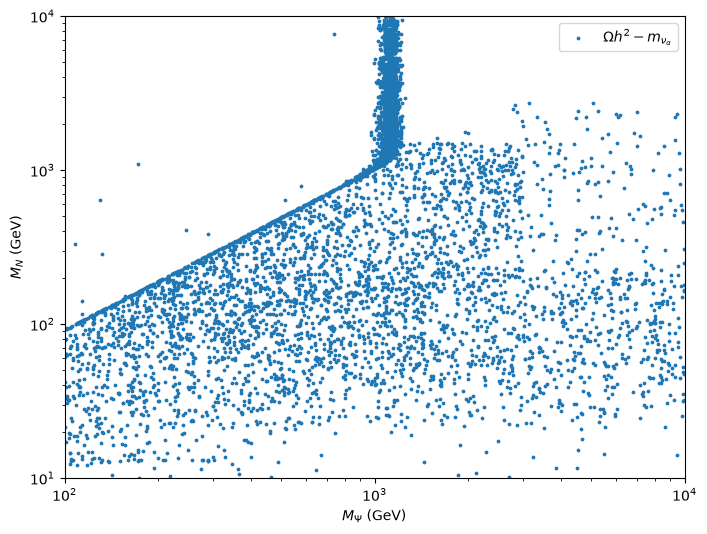

In [79]:
Mphi = df_sd["MDF"]
MN = df_sd['YRC'] * df_sd['vS'] / np.sqrt(2) # Cálculo de M_N

plt.figure(figsize=(8, 6))
plt.scatter(Mphi, MN, s=3, label=r"$\Omega h^2 - m_{\nu_\alpha}$")
plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$M_\Psi$ (GeV)")
plt.ylabel(r"$M_N$ (GeV)")
plt.xlim(1e2, 1e4) # límites que se ven en la gráfica del paper
plt.ylim(1e1, 1e4)
plt.legend()

plt.show()

BIEN. FALTO EN LA SEGUNDA GRAFICA...
NOTA: 2.2+1.8